# 05. Анализ выживаемости

Модели, построенные в ноутбуке 04, отвечают на вопрос о факте наступления события. Настоящий ноутбук рассматривает вопрос о времени его наступления, а также решает задачу, недоступную бинарной классификации, — корректный учёт цензурирования справа.

Часть учеников на момент окончания наблюдения не приобрела второй курс, что не означает отказа от покупки: период наблюдения завершился раньше события. Модель бинарной классификации относит такие наблюдения к отрицательному классу, что приводит к смещению оценок. Модели времени до события учитывают цензурирование корректно.

Рассматриваются два события: выбытие с первого курса и приобретение второго курса. Точка отсчёта для обоих — день начала первого курса.

In [1]:
import sqlite3
from contextlib import closing

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lifelines import CoxPHFitter, CoxTimeVaryingFitter, KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

DB_PATH = '../data/churn.db'
DATE_COLUMNS = ['first_course_start_date', 'first_course_end_date',
                'group_churn_date', 'second_course_payment_date']
RARE_COURSE_THRESHOLD = 100

sns.set_theme(style='whitegrid', rc={'font.family': 'DejaVu Sans'})


def load_table(name):
    with closing(sqlite3.connect(DB_PATH)) as conn:
        frame = pd.read_sql_query(f'SELECT * FROM {name}', conn)
    for column in [c for c in DATE_COLUMNS if c in frame.columns]:
        frame[column] = pd.to_datetime(frame[column])
    return frame


df = load_table('model_input')
for column in ['dropped_out', 'bought_second', 'bought_before_course_end']:
    df[column] = df[column].astype(bool)

print(f'Загружено: {len(df):,} студентов')

Загружено: 5,900 студентов


## Определение событий и цензурирования

**Выбытие с первого курса.** Событие фиксируется датой в поле `group_churn_date`. Наблюдения без выбытия цензурируются датой завершения курса, поскольку после неё событие невозможно.

**Приобретение второго курса.** Событие фиксируется датой платежа. Наблюдения без покупки цензурируются границей горизонта данных — 1 марта 2026 года.

In [2]:
survival = df.copy()

survival['dropout_duration'] = np.where(
    survival['dropped_out'], survival['days_to_dropout'], survival['course_duration_days'])
survival['dropout_event'] = survival['dropped_out'].astype(int)

survival['purchase_duration'] = np.where(
    survival['bought_second'], survival['days_to_second'], survival['observed_days'])
survival['purchase_event'] = survival['bought_second'].astype(int)

for column in ['dropout_duration', 'purchase_duration']:
    survival[column] = survival[column].clip(lower=1)

display(pd.DataFrame([
    {'Событие': 'Уход с первого курса', 'Наблюдений': len(survival),
     'Событий': int(survival['dropout_event'].sum()),
     'Доля событий, %': round(survival['dropout_event'].mean() * 100, 1),
     'Медиана времени, дней': float(survival.loc[survival['dropout_event'] == 1, 'dropout_duration'].median())},
    {'Событие': 'Покупка второго курса', 'Наблюдений': len(survival),
     'Событий': int(survival['purchase_event'].sum()),
     'Доля событий, %': round(survival['purchase_event'].mean() * 100, 1),
     'Медиана времени, дней': float(survival.loc[survival['purchase_event'] == 1, 'purchase_duration'].median())},
]))

,Событие,Наблюдений,Событий,"Доля событий, %","Медиана времени, дней"
0,Уход с первого курса,5900,3105,52.6,56.0
1,Покупка второго курса,5900,1947,33.0,107.0


## Функции выживания

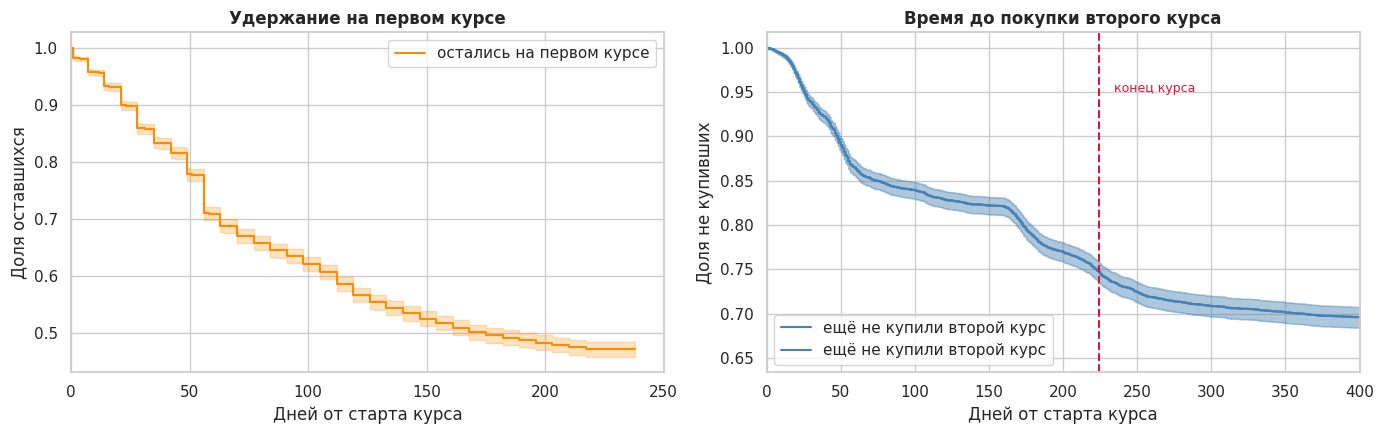

,День,"Остались на курсе, %","Ещё не купили, %"
0,30,85.9,93.8
1,60,70.9,86.3
2,90,64.5,84.2
3,120,56.7,82.9
4,180,49.6,78.7
5,240,47.1,73.0
6,365,47.1,69.9


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

dropout_curve = KaplanMeierFitter()
dropout_curve.fit(survival['dropout_duration'], survival['dropout_event'],
                  label='остались на первом курсе')
dropout_curve.plot_survival_function(ax=axes[0], color='darkorange')
axes[0].set_title('Удержание на первом курсе', fontweight='bold')
axes[0].set_xlabel('Дней от старта курса')
axes[0].set_ylabel('Доля оставшихся')
axes[0].set_xlim(0, 250)

purchase_curve = KaplanMeierFitter()
purchase_curve.fit(survival['purchase_duration'], survival['purchase_event'],
                   label='ещё не купили второй курс')
purchase_curve.plot_survival_function(ax=axes[1], color='steelblue')
purchase_curve.plot_survival_function(ax=axes[1], color='steelblue')
axes[1].axvline(survival['course_duration_days'].median(), color='crimson',
                linestyle='--', linewidth=1.5)
axes[1].text(survival['course_duration_days'].median() + 10, 0.95, 'конец курса',
             color='crimson', fontsize=9)
axes[1].set_title('Время до покупки второго курса', fontweight='bold')
axes[1].set_xlabel('Дней от старта курса')
axes[1].set_ylabel('Доля не купивших')
axes[1].set_xlim(0, 400)

plt.tight_layout()
plt.show()

milestones = [30, 60, 90, 120, 180, 240, 365]
display(pd.DataFrame({
    'День': milestones,
    'Остались на курсе, %': [round(float(dropout_curve.predict(d)) * 100, 1) for d in milestones],
    'Ещё не купили, %': [round(float(purchase_curve.predict(d)) * 100, 1) for d in milestones],
}))

### Динамика удержания и повторных покупок

Функция удержания на первом курсе снижается интенсивно и на раннем этапе: к 30-му дню остаётся 85.9% учеников, к 60-му — 70.9%, к 120-му — 56.7%. После 180 дней кривая выходит на плато на уровне 47.1%, что соответствует завершению курса.

Функция для повторных покупок имеет иную форму: основное снижение приходится на первые два месяца (86.3% к 60-му дню), далее темп существенно замедляется. К 240-му дню не совершили покупку 73.0%, к 365-му — 69.9%. За четыре месяца после завершения курса прирост составляет около трёх процентных пунктов.

Обе функции указывают на концентрацию значимых событий в первые два-три месяца обучения, что определяет период приоритетного управленческого воздействия.

## Сегментные различия

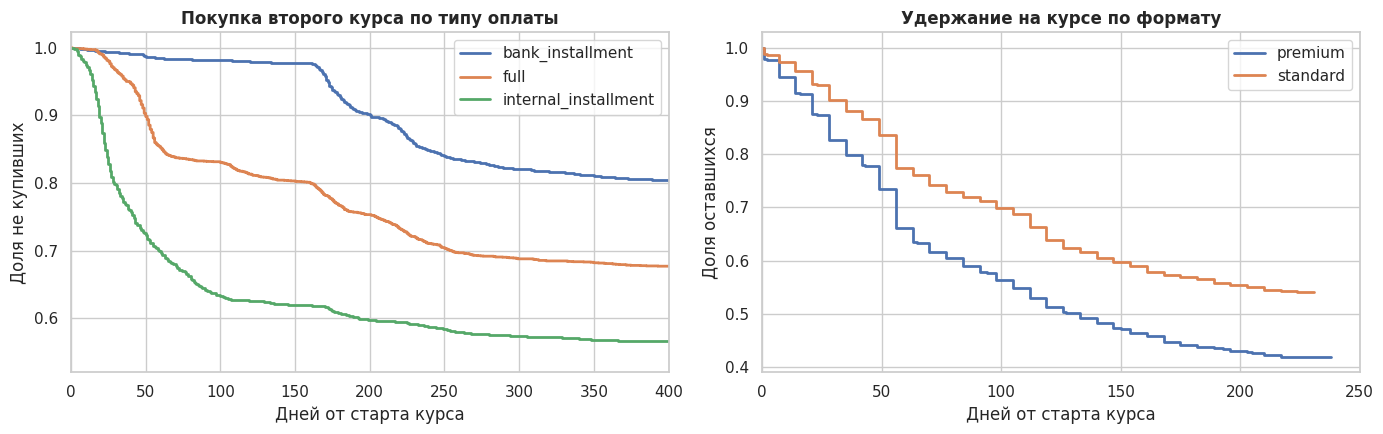

Лог-ранговый тест: различаются ли кривые покупки по типу оплаты
статистика = 268.8, p-value = 4.356e-59
Вывод: кривые различаются


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for segment, group in survival.groupby('payment_type_group', observed=True):
    curve = KaplanMeierFitter()
    curve.fit(group['purchase_duration'], group['purchase_event'], label=segment)
    curve.plot_survival_function(ax=axes[0], ci_show=False, linewidth=2)

axes[0].set_title('Покупка второго курса по типу оплаты', fontweight='bold')
axes[0].set_xlabel('Дней от старта курса')
axes[0].set_ylabel('Доля не купивших')
axes[0].set_xlim(0, 400)

for segment, group in survival.groupby('course_format_group', observed=True):
    curve = KaplanMeierFitter()
    curve.fit(group['dropout_duration'], group['dropout_event'], label=segment)
    curve.plot_survival_function(ax=axes[1], ci_show=False, linewidth=2)

axes[1].set_title('Удержание на курсе по формату', fontweight='bold')
axes[1].set_xlabel('Дней от старта курса')
axes[1].set_ylabel('Доля оставшихся')
axes[1].set_xlim(0, 250)

plt.tight_layout()
plt.show()

logrank = multivariate_logrank_test(survival['purchase_duration'],
                                    survival['payment_type_group'],
                                    survival['purchase_event'])

print('Лог-ранговый тест: различаются ли кривые покупки по типу оплаты')
print(f'статистика = {logrank.test_statistic:.1f}, p-value = {logrank.p_value:.3e}')
print('Вывод: кривые различаются' if logrank.p_value < 0.05 else 'Вывод: различий нет')

### Различия функций выживания по типу оплаты

Логранговый критерий применён на основании характера данных: он является единственным корректным способом сравнения функций выживания при наличии цензурированных наблюдений, тогда как обычное сравнение долей не учитывает различия в длительности наблюдения. Это вторая и последняя процедура проверки гипотез в работе.

Различия между типами оплаты существенны, значение статистики составляет 268.8. Кривые различаются не только по уровню, но и по форме: внутренняя рассрочка характеризуется резким снижением в первые недели, банковская — практически горизонтальным участком. Полученная картина соответствует медианным значениям 34 и 218 дней, установленным в ноутбуке 03.

## Модель пропорциональных рисков Кокса

In [5]:
ENROLLMENT_COVARIATES = ['age', 'gender', 'utm_source_group',
                         'course_format_group', 'payment_type_group', 'course_group']

course_counts = survival['course_group'].value_counts()
rare_courses = course_counts.index[course_counts < RARE_COURSE_THRESHOLD]
survival['course_group_model'] = survival['course_group'].where(
    ~survival['course_group'].isin(rare_courses), 'other')

print(f'Редких курсов свёрнуто в other: {len(rare_courses)} '
      f'({int(survival["course_group"].isin(rare_courses).sum())} студентов)')

cox_frame = pd.get_dummies(
    survival[['purchase_duration', 'purchase_event', 'age', 'gender', 'utm_source_group',
              'course_format_group', 'payment_type_group', 'course_group_model']],
    drop_first=True, dtype=float)

cox = CoxPHFitter(penalizer=0.01)
cox.fit(cox_frame, duration_col='purchase_duration', event_col='purchase_event')

print(f'C-индекс: {cox.concordance_index_:.3f}')
display(cox.summary[['coef', 'exp(coef)', 'p']].sort_values('coef', key=abs, ascending=False).head(12).round(3))

Редких курсов свёрнуто в other: 11 (331 студентов)
C-индекс: 0.647


,coef,exp(coef),p
covariate,,,
payment_type_group_internal_installment,1.029,2.800,0.000
payment_type_group_full,0.511,1.667,0.000
utm_source_group_telegram,-0.474,0.622,0.132
utm_source_group_influencer,0.444,1.559,0.089
gender_UNKNOWN,-0.399,0.671,0.000
course_group_model_unity,0.399,1.490,0.009
utm_source_group_social,0.373,1.452,0.063
utm_source_group_website,0.299,1.348,0.106
course_group_model_scratch,-0.240,0.787,0.012


### Результаты оценивания модели Кокса

В модель включены исключительно признаки, известные на момент зачисления. Поведенческие агрегаты не используются: они рассчитаны за весь период обучения, тогда как модель отсчитывает время от его начала, вследствие чего такие признаки содержали бы информацию из будущего.

Курсы с численностью менее 100 учеников объединены в категорию `other`: при девятнадцати категориях отдельные группы насчитывают около десяти наблюдений, что делает оценки коэффициентов неустойчивыми.

Значение C-индекса составляет 0.647, что соответствует умеренному качеству ранжирования и сопоставимо с моделью A из предыдущего ноутбука при идентичном составе признаков.

Базовая категория по типу оплаты — банковская рассрочка. Относительно неё внутренняя рассрочка соответствует интенсивности покупки, превышающей базовую в 2.8 раза, полная оплата — в 1.67 раза. Под интенсивностью понимается мгновенная вероятность наступления события при условии его ненаступления к данному моменту.

## Проверка допущений модели

In [6]:
print('Диагностика пропорциональности рисков (остатки Шёнфельда)')
cox.check_assumptions(cox_frame, p_value_threshold=0.01, show_plots=False)

Диагностика пропорциональности рисков (остатки Шёнфельда)


The ``p_value_threshold`` is set at 0.01. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'gender_UNKNOWN' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['gender_UNKNOWN', ...]` in
the call in `.fit`. See documentation in link [E] below.

2. Variable 'payment_type_group_full' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['payment_type_group_full',
...]` in the call in `.fit`. See documentation in link [E] below.

3. Variable 'payment_type_group_internal_installment' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include
`strata=['payment_type_group_internal_installment', ...]` in the call in `.fit`. See documentation
in link [E] below.

4. Variable 'course_group_model_funtech' failed the non-proportional test: p-value is 0.0007.

   Advice: with so few unique values (only 2), you can include
`strata=['course_group_model_funtech', ...]` in the 

[]

### Нарушение допущения пропорциональности рисков

Модель Кокса предполагает постоянство отношения рисков между группами во времени. Анализ остатков Шёнфельда выявил нарушение данного допущения для шести переменных, включая оба типа оплаты.

Формально это ограничивает интерпретацию: приведённые коэффициенты следует рассматривать как усреднённый по периоду наблюдения эффект, а не как постоянное отношение рисков. Вместе с тем само нарушение имеет содержательный характер и представляет самостоятельный результат: эффект типа оплаты изменяется во времени, что подтверждается формой функций выживания — внутренняя рассрочка обеспечивает всплеск покупок в первые недели, банковская выходит на сопоставимые темпы через полгода. Единым коэффициентом такая динамика не описывается.

Для формального устранения нарушения применимы стратифицированная модель либо включение взаимодействия со временем. Для практических целей достаточен вывод о необходимости различных сроков управленческого воздействия на данные сегменты.

Анализ остатков Шёнфельда представляет собой проверку применимости модели, а не проверку гипотезы о свойствах данных, вследствие чего не учитывается в числе статистических критериев работы.

## Учёт выбытия как изменяющегося во времени фактора

In [7]:
long_format = []
for row in survival.itertuples():
    stop = float(row.purchase_duration)
    event = int(row.purchase_event)
    dropout_time = row.days_to_dropout

    if pd.notna(dropout_time) and 0 < dropout_time < stop:
        long_format.append((row.id, 0.0, float(dropout_time), 0, 0))
        long_format.append((row.id, float(dropout_time), stop, event, 1))
    else:
        long_format.append((row.id, 0.0, stop, event, 0))

long_frame = pd.DataFrame(long_format, columns=['id', 'start', 'stop', 'event', 'left_the_group'])

static = pd.get_dummies(
    survival[['id', 'age', 'course_format_group', 'payment_type_group']],
    columns=['course_format_group', 'payment_type_group'], drop_first=True, dtype=float)

long_frame = long_frame.merge(static, on='id', how='left')

print(f'Строк в длинном формате: {len(long_frame):,} на {long_frame["id"].nunique():,} студентов')

time_varying_cox = CoxTimeVaryingFitter(penalizer=0.01)
time_varying_cox.fit(long_frame, id_col='id', event_col='event',
                     start_col='start', stop_col='stop', show_progress=False)

display(time_varying_cox.summary[['coef', 'exp(coef)', 'p']].round(3))

Строк в длинном формате: 8,543 на 5,900 студентов


,coef,exp(coef),p
covariate,,,
left_the_group,-1.050,0.350,0.000
age,0.037,1.038,0.000
course_format_group_standard,0.162,1.176,0.001
payment_type_group_full,0.600,1.822,0.000
payment_type_group_internal_installment,1.093,2.984,0.000


### Корректная оценка эффекта выбытия

Включение индикатора выбытия из группы в качестве статического признака методологически некорректно: выбытие происходит в течение периода наблюдения, а не предшествует ему. Ученик, приобретший второй курс на 40-й день и выбывший на 90-й, в такой модели классифицировался бы как выбывший при совершении покупки, тогда как на момент покупки он оставался в группе. Это соответствует систематической ошибке бессмертного времени, при которой часть периода наблюдения приписывается состоянию, ещё не наступившему.

Корректный подход состоит в разбиении периода наблюдения каждого ученика на интервалы: до момента выбытия признак принимает нулевое значение, после — единичное. Для 5 900 учеников формируется 8 543 интервала.

Результат оценивания: после выбытия из группы интенсивность приобретения второго курса снижается до 0.35 от исходного уровня, то есть практически втрое. Тип оплаты сохраняет значимость и в данной спецификации, возраст соответствует приросту интенсивности на 3.8% на каждый год.

,Группа,Студентов,"Купили второй курс, %"
0,ушли из группы до покупки,2747,13.8
1,не уходили,3153,49.7


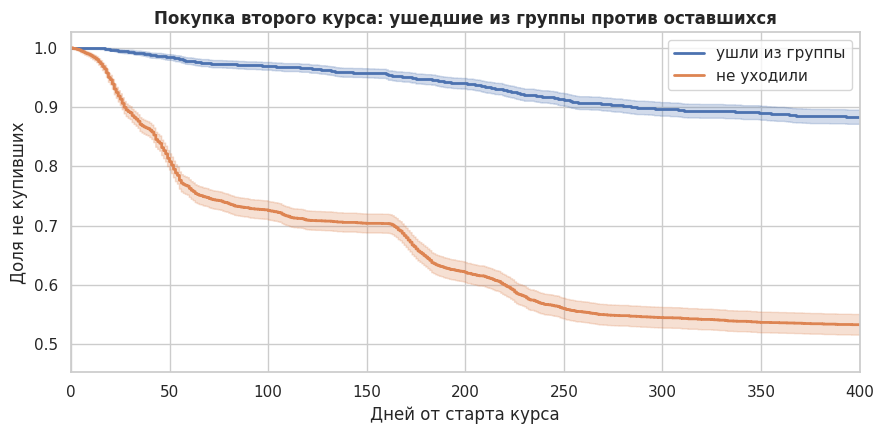

In [8]:
naive = survival.copy()
naive['dropped_before_purchase'] = (
    naive['days_to_dropout'].notna() & (naive['days_to_dropout'] < naive['purchase_duration']))

comparison = pd.DataFrame([
    {'Группа': 'ушли из группы до покупки', 'Студентов': int(naive['dropped_before_purchase'].sum()),
     'Купили второй курс, %': round(naive.loc[naive['dropped_before_purchase'], 'bought_second'].mean() * 100, 1)},
    {'Группа': 'не уходили', 'Студентов': int((~naive['dropped_before_purchase']).sum()),
     'Купили второй курс, %': round(naive.loc[~naive['dropped_before_purchase'], 'bought_second'].mean() * 100, 1)},
])

display(comparison)

fig, axis = plt.subplots(figsize=(9, 4.5))
for label, mask in [('ушли из группы', naive['dropped_before_purchase']),
                    ('не уходили', ~naive['dropped_before_purchase'])]:
    curve = KaplanMeierFitter()
    curve.fit(naive.loc[mask, 'purchase_duration'], naive.loc[mask, 'purchase_event'], label=label)
    curve.plot_survival_function(ax=axis, ci_show=True, linewidth=2)

axis.set_title('Покупка второго курса: ушедшие из группы против оставшихся', fontweight='bold')
axis.set_xlabel('Дней от старта курса')
axis.set_ylabel('Доля не купивших')
axis.set_xlim(0, 400)
plt.tight_layout()
plt.show()

### Сопоставление с оценкой без учёта времени

Для сравнения приводится та же связь, рассчитанная без учёта временной структуры: среди выбывших до момента покупки второй курс приобрели 13.8%, среди не выбывших — 49.7%.

Сравнивать эти доли с коэффициентом модели напрямую нельзя: отношение долей и отношение интенсивностей — разные показатели, и приведение их к общему знаменателю требует дополнительных допущений. Сопоставление показывает только направление смещения: расчёт без учёта времени относит к состоянию «выбыл» весь период наблюдения ученика, включая время до выбытия, и потому преувеличивает различие между группами.

Следует отметить, что выбытие не является конкурирующим риском. Конкурирующий риск по определению исключает наступление основного события, тогда как 804 выбывших ученика впоследствии приобрели второй курс. Вследствие этого расчёт кумулятивной функции инцидентности не требуется, и модель с изменяющимся во времени признаком является достаточной.

## Выводы

1. **Половина выбытия с первого курса приходится на первые два месяца обучения.** Функция удержания снижается до 70.9% к 60-му дню и выходит на плато на уровне 47%.
2. **Повторные покупки также концентрируются на раннем этапе.** К 60-му дню функция выживания проходит основной участок снижения, далее динамика близка к горизонтальной.
3. **Тип оплаты является определяющим фактором скорости повторной покупки.** Внутренняя рассрочка соответствует интенсивности, практически втрое превышающей интенсивность в группе банковской рассрочки.
4. **Эффект типа оплаты непостоянен во времени** — допущение пропорциональности рисков нарушено. Приведённые коэффициенты следует читать как усреднённый по периоду наблюдения эффект.
5. **Выбытие из группы снижает интенсивность повторной покупки втрое, но не исключает её.** Оценка получена без систематической ошибки бессмертного времени.